In [1]:
%pip install gin-config
%pip install absl-py
%pip install gym==0.23.0
%pip install matplot

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [5]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import re
from concurrent.futures import ThreadPoolExecutor, as_completed
import tensorflow as tf
import numpy as np 
import numpy as np
import requests 
import time

# TF‑Agents imports  
from tf_agents.environments import tf_py_environment  
from tf_agents.trajectories import trajectory
from tf_agents.networks import q_network
from tf_agents.agents.dqn import dqn_agent
from tf_agents.utils import common
from tf_agents.replay_buffers import tf_uniform_replay_buffer 
from tf_agents.policies import epsilon_greedy_policy

from tf_agents.environments import py_environment
from tf_agents.specs import array_spec
from tf_agents.trajectories import time_step as ts

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [6]:
def getResponseFromServer():
    url = 'http://localhost:8005'

    try:
        response = requests.get(url)

        if response.status_code == 200:
            print("Successfully received response from load balancer")
            return
        else:
            print('Error:', response.status_code)
            return None
    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return None

In [7]:
getResponseFromServer()

Successfully received response from load balancer


In [8]:

SERVER_METRICS_URL = "http://localhost:8005" + "/server-metrics"
global SERVERS
SERVERS = [
    "http://127.0.0.1:8000",
    "http://127.0.0.1:8001",
    "http://127.0.0.1:8002"
]

In [9]:
def _parse_prometheus_metrics(metrics_text: str) -> dict:
    """Extract aggregated metrics from Prometheus text format."""
    failed_count_match = re.search(
        r'flask_http_request_total\{method="GET",status="429"\}\s+([\d.]+)', metrics_text)
    failed_count = float(failed_count_match.group(1)) if failed_count_match else 0.0

    success_count_match = re.search(
        r'flask_http_request_total\{method="GET",status="200"\}\s+([\d.]+)', metrics_text)
    success_count = float(success_count_match.group(1)) if success_count_match else 0.0

    total_requests = failed_count + success_count

    success_sum_match = re.search(
        r'flask_http_request_duration_seconds_sum\{method="GET",path="/heavy-task",status="200"\}\s+([\d.]+)', metrics_text)
    success_sum = float(success_sum_match.group(1)) if success_sum_match else 0.0

    success_time_count_match = re.search(
        r'flask_http_request_duration_seconds_count\{method="GET",path="/heavy-task",status="200"\}\s+([\d.]+)', metrics_text)
    success_time_count = float(success_time_count_match.group(1)) if success_time_count_match else 0.0

    avg_success_response = success_sum / success_time_count if success_time_count > 0 else 0.0

    failed_to_success_ratio = failed_count / success_count if success_count > 0 else (float('inf') if total_requests > 0 else 0.5)

    return {
        "avg_successful_response_time": avg_success_response,
        "total_requests": total_requests,
        "failed_to_success_ratio": failed_to_success_ratio
    }

In [10]:
def generate_state(serverUrl):
    latency = []
    requests_handled = []
    failed_to_success_ratio = []

    for server in SERVERS:
        try:
            response = requests.get(f"{server}/metrics", timeout=2)
            response.raise_for_status()
            backend_metrics = _parse_prometheus_metrics(response.text)

            print(f"{server}: {backend_metrics}")

            raw_latency = backend_metrics.get("avg_successful_response_time", 0.0)
            latency.append(min(raw_latency / 5.0, 1.0))
            raw_requests = backend_metrics.get("total_requests", 0.0)
            requests_handled.append(min(raw_requests / 10000, 1.0))
            failed_to_success_ratio.append(backend_metrics.get("failed_to_success_ratio", 0.5))
        except requests.RequestException as e:
            print(f"Error fetching metrics from {server}: {e}")
            latency.append(1.0)
            requests_handled.append(0.0)
            failed_to_success_ratio.append(0.5)
      
    state = np.column_stack([latency, requests_handled, failed_to_success_ratio])
    return state.astype(np.float32)

In [11]:

state = generate_state(SERVER_METRICS_URL)
print("Generated state:\n", state)

http://127.0.0.1:8000: {'avg_successful_response_time': 0.3855351282805769, 'total_requests': 388.0, 'failed_to_success_ratio': 0.375886524822695}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.39649687652542653, 'total_requests': 271.0, 'failed_to_success_ratio': 0.19383259911894274}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.410854997681887, 'total_requests': 277.0, 'failed_to_success_ratio': 0.5919540229885057}
Generated state:
 [[0.07710703 0.0388     0.37588653]
 [0.07929938 0.0271     0.1938326 ]
 [0.082171   0.0277     0.59195405]]


In [12]:
def compute_reward_from_state(state_row, alpha=1.0, beta=1.0, gamma=1.0):
    """
    Compute a reward from a state row (NumPy array) representing a server's metrics.
    
    Args:
      state_row (numpy.array): Array with [latency, total_requests, failed_to_success_ratio].
      alpha (float): Weight for latency penalty.
      beta (float): Weight for failure ratio penalty.
      gamma (float): Weight for throughput reward.
      
    Returns:
      float: Computed reward.
    """
    latency = state_row[0]
    total_requests = state_row[1]
    failure_ratio = state_row[2]
    
    # latency is normalized by /5.0, so 1.5s = 1.5/5.0 = 0.3
    SLA_THRESHOLD = 0.3  #equivalent to 1.5 seconds in normalized space
    latency_penalty = max(0, latency - SLA_THRESHOLD)
    reward = -(alpha * latency_penalty + beta * failure_ratio)

    
    return reward

In [13]:
class LoadBalancerEnv(py_environment.PyEnvironment):
    MAX_LATENCY   = 5.0     # seconds
    MAX_REQUESTS  = 10000.0
    def __init__(self, serverMetricsUrl, servers):
        """
        Args:
          serverMetricsUrl: URL that returns aggregated server metrics in JSON format.
          servers: List of server URLs 
        """
        super(LoadBalancerEnv, self).__init__()
        self._servers = servers
        self._num_servers = len(servers)
        self._serverMetricsUrl = serverMetricsUrl

        # Observation: For each server, we consider 3 metrics:
        # [avg_successful_response_time (latency), total_requests, failed_to_success_ratio]
        self._observation_spec = array_spec.BoundedArraySpec(
            shape=(self._num_servers, 3),
            dtype=np.float32,
            minimum=0.0,
            maximum=1.0,
            name='observation'
        )

        # Action: A single discrete action representing the server index (0 to num_servers-1).
        self._action_spec = array_spec.BoundedArraySpec(
            shape=(),
            dtype=np.int32,
            minimum=0,
            maximum=self._num_servers - 1,
            name='action'
        )

        self._episode_ended = False
        self._step_count = 0
        self._max_steps = 100  # defines the episode length

        # Initialize state by fetching the metrics
        self._state = self._generate_state()

    def _generate_state(self):
        """
        Fetch performance metrics from the aggregated metrics endpoint.
        For each server, extract:
          - avg_successful_response_time (latency)
          - total_requests
          - failed_to_success_ratio
        Returns a (num_servers, 3) numpy array.
        """
        latency = []
        requests_handled = []
        failed_to_success_ratio = []
        
        for server in SERVERS:
            try:
                response = requests.get(f"{server}/metrics", timeout=2)
                response.raise_for_status()
                backend_metrics = _parse_prometheus_metrics(response.text)

                print(f"{server}: {backend_metrics}")

                raw_latency = backend_metrics.get("avg_successful_response_time", 1.0)
                latency.append(min(raw_latency / 5.0, 1.0))
                raw_requests = backend_metrics.get("total_requests", 0.0)
                requests_handled.append(min(raw_requests / 10000, 1.0))
                failed_to_success_ratio.append(backend_metrics.get("failed_to_success_ratio", 0.5))
            except requests.RequestException as e:
                print(f"Error fetching metrics from {server}: {e}")
                latency.append(1.0)
                requests_handled.append(0.0)
                failed_to_success_ratio.append(0.5)
        
        state = np.column_stack([latency, requests_handled, failed_to_success_ratio])
        return state.astype(np.float32)

    def action_spec(self):
        return self._action_spec

    def observation_spec(self):
        return self._observation_spec

    def _reset(self):
        self._episode_ended = False
        self._step_count = 0
        self._state = self._generate_state()
        return ts.restart(self._state)

    def _step(self, action):
        if self._episode_ended:
            return self.reset()

        self._step_count += 1

        # Discrete action: chosen server index (0, 1, or 2)
        chosen_index = int(action)
        chosen_server = self._servers[chosen_index]
        print(f"Routing new traffic to chosen server: {chosen_server}")

        # Define total number of simulated requests
        total_requests = 30
        chosen_requests = int(total_requests * 0.7)  # 70% to chosen server
        remaining_requests = total_requests - chosen_requests  # 30% to others

        # Instead of all at once, send in small batches
        batch_size = 10
        delay_between_batches = 0.1  # 100ms

        # Determine indices of other servers
        other_indices = [i for i in range(self._num_servers) if i != chosen_index]
         
        request_targets = [f"{chosen_server}/heavy-task"] * chosen_requests
         
        for _ in range(remaining_requests):
            random_index = np.random.choice(other_indices)
            request_targets.append(f"{self._servers[random_index]}/heavy-task")
        
        # Send the requests concurrently using ThreadPoolExecutor
        responses = []
        for i in range(0, len(request_targets), batch_size):
            batch = request_targets[i:i + batch_size]
            with ThreadPoolExecutor(max_workers=batch_size) as executor:
                futures = [executor.submit(requests.get, target, timeout=5) for target in batch]
                for future in as_completed(futures):
                    try:
                        resp = future.result()
                        responses.append(resp.status_code)
                    except Exception as e:
                        responses.append(None)
            time.sleep(delay_between_batches)

 
        success_count = sum(1 for r in responses if r == 200)
        failure_count = sum(1 for r in responses if r is None or r != 200)

        print(f"Simulated traffic: {success_count} successes, {failure_count} failures.")
 
        new_state = self._generate_state() 
         
        reward = compute_reward_from_state(new_state[chosen_index])

        print(f"Reward: {reward}")
 
        self._state = new_state

        if self._step_count >= self._max_steps:
            self._episode_ended = True
            return ts.termination(self._state, reward)
        else:
            return ts.transition(self._state, reward=reward, discount=0.99)

In [14]:
loadBalancerEnv = LoadBalancerEnv(SERVER_METRICS_URL, SERVERS)
    
# Reset the environment and print the initial state 
initial_time_step = loadBalancerEnv.reset()
print("Initial state:\n", initial_time_step.observation)
    
# Simulate one step with an example action (e.g., choose server 1)
time_step = loadBalancerEnv._step(1)
print("New state:\n", time_step.observation)
print("Reward:", time_step.reward)

http://127.0.0.1:8000: {'avg_successful_response_time': 0.3855351282805769, 'total_requests': 388.0, 'failed_to_success_ratio': 0.375886524822695}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.39649687652542653, 'total_requests': 271.0, 'failed_to_success_ratio': 0.19383259911894274}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.410854997681887, 'total_requests': 277.0, 'failed_to_success_ratio': 0.5919540229885057}
http://127.0.0.1:8000: {'avg_successful_response_time': 0.3855351282805769, 'total_requests': 388.0, 'failed_to_success_ratio': 0.375886524822695}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.39649687652542653, 'total_requests': 271.0, 'failed_to_success_ratio': 0.19383259911894274}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.410854997681887, 'total_requests': 277.0, 'failed_to_success_ratio': 0.5919540229885057}
Initial state:
 [[0.07710703 0.0388     0.37588653]
 [0.07929938 0.0271     0.1938326 ]
 [0.082171   0.0277     

In [15]:

GAMMA = 0.99
NEURAL_NETWORK_HIDDEN_UNITS = (64,64)
MAX_BUFFER_SIZE = 10000
LEARNING_RATE = 5e-5 

In [16]:

# -----------------------------------------------------------------------------
# 2. Create the TF-Agents Environment and the DQN Agent
# ----------------------------------------------------------------------------- 
 
train_env = tf_py_environment.TFPyEnvironment(loadBalancerEnv)
 
fc_layer_params = NEURAL_NETWORK_HIDDEN_UNITS
q_net = q_network.QNetwork(
    train_env.observation_spec(),
    train_env.action_spec(),
    fc_layer_params=fc_layer_params)
 
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=LEARNING_RATE)

# Creating a counter to keep track of the training steps.
train_step_counter = tf.Variable(0)
  
agent = dqn_agent.DqnAgent(
    train_env.time_step_spec(),
    train_env.action_spec(),
    q_network=q_net,
    optimizer=optimizer,
    gamma = GAMMA,
    target_update_tau = 1,
    target_update_period=100,
    td_errors_loss_fn = common.element_wise_huber_loss,
    train_step_counter=train_step_counter)

agent.initialize()

In [17]:
# ---------------------------------------------------------------------------
# 3. Setup the Replay Buffer and Data Collection for Training
# ---------------------------------------------------------------------------

replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.collect_data_spec,
    batch_size=train_env.batch_size,
    max_length=MAX_BUFFER_SIZE
)

EPSILON_GREEDY_START = 1.0
EPSILON_GREEDY_END   = 0.1
EPSILON_DECAY_STEPS  = 1000

epsilon = tf.compat.v1.train.polynomial_decay(
    learning_rate=EPSILON_GREEDY_START,
    global_step=train_step_counter,
    decay_steps=EPSILON_DECAY_STEPS,
    end_learning_rate=EPSILON_GREEDY_END
)

collect_policy = epsilon_greedy_policy.EpsilonGreedyPolicy(
    agent.policy, epsilon=epsilon
)

def collect_step(environment, policy, buffer):
    """Collects a single transition and stores it in the replay buffer."""
    time_step = environment.current_time_step()  
    action_step = policy.action(time_step)  
    next_time_step = environment.step(action_step.action)  
    traj = trajectory.from_transition(time_step, action_step, next_time_step)  
    buffer.add_batch(traj)

# Collect initial experience for the agent to learn from
initial_collect_steps = 500  
print(f"Collecting {initial_collect_steps} initial experience steps...")

for _ in range(initial_collect_steps):
    collect_step(train_env, collect_policy, replay_buffer)

# Create a dataset from the replay buffer for training
batch_size = 64
num_steps = 2   

dataset = replay_buffer.as_dataset(
    sample_batch_size=batch_size,
    num_steps=num_steps
).prefetch(3)

iterator = iter(dataset) 

http://127.0.0.1:8000: {'avg_successful_response_time': 0.38375728018581867, 'total_requests': 395.0, 'failed_to_success_ratio': 0.36678200692041524}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.3927887982419251, 'total_requests': 292.0, 'failed_to_success_ratio': 0.20164609053497942}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.4089344755642944, 'total_requests': 279.0, 'failed_to_success_ratio': 0.5852272727272727}
Routing new traffic to chosen server: http://127.0.0.1:8001
Simulated traffic: 25 successes, 5 failures.
http://127.0.0.1:8000: {'avg_successful_response_time': 0.38023953090675855, 'total_requests': 399.0, 'failed_to_success_ratio': 0.36177474402730375}
http://127.0.0.1:8001: {'avg_successful_response_time': 0.38760170538802274, 'total_requests': 313.0, 'failed_to_success_ratio': 0.2084942084942085}
http://127.0.0.1:8002: {'avg_successful_response_time': 0.410424526007846, 'total_requests': 284.0, 'failed_to_success_ratio': 0.569060773480663}
Rew

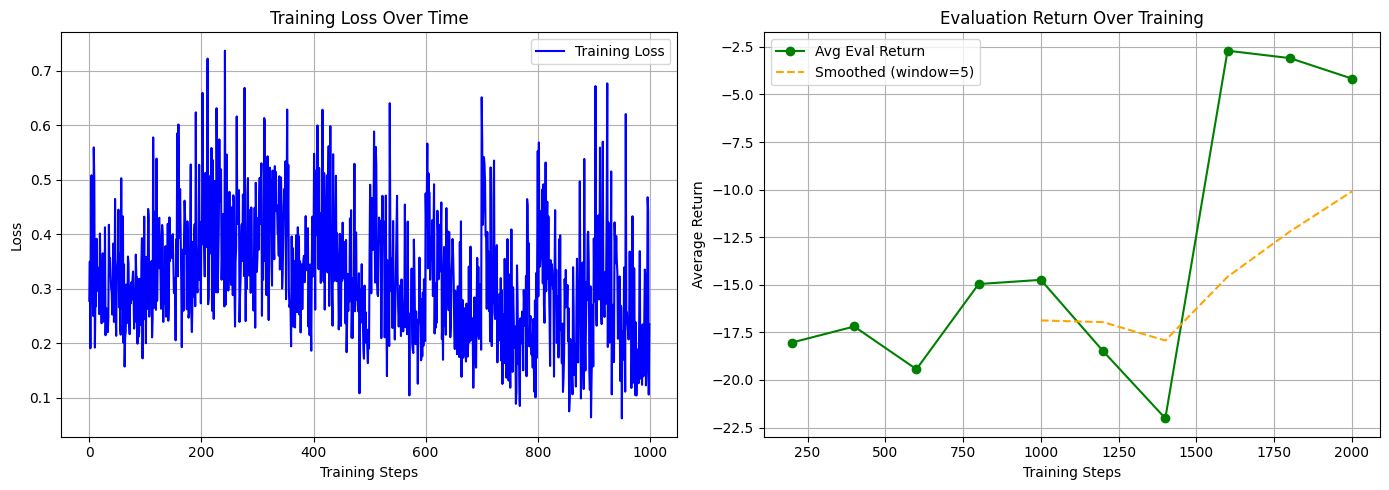

Training completed successfully.


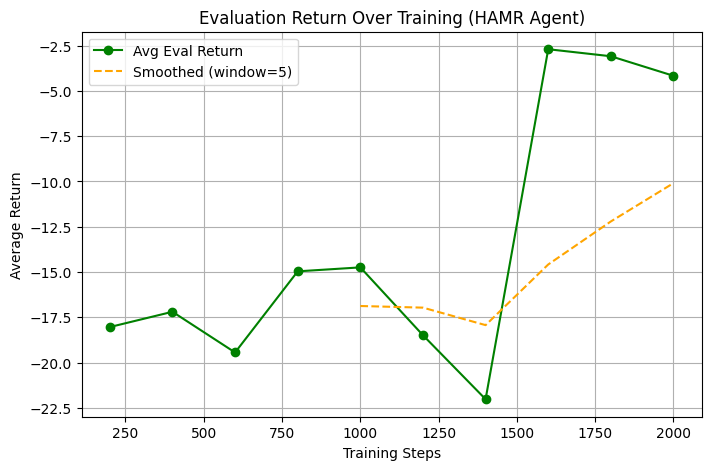

In [18]:
#new claude code for training

import matplotlib.pyplot as plt
import os
import numpy as np
from IPython.display import clear_output

plot_dir = "training_plots"
os.makedirs(plot_dir, exist_ok=True)

# ---------------------------------------------------------------------------
# 4. Training the Agent with Visualization
# ---------------------------------------------------------------------------

num_iterations = 1000
train_loss_history = []
eval_returns_history = []       # NEW
eval_steps_history = []         # NEW: x-axis points for reward curve

eval_interval = 200              # NEW: evaluate every 50 steps
num_eval_episodes = 1         # NEW: average over 5 episodes for stability

def evaluate_agent(env, policy, num_episodes, max_eval_steps=20):
    """Run greedy policy for num_episodes, return average return."""
    total_return = 0.0
    for _ in range(num_episodes):
        time_step = env.reset()
        episode_return = 0.0
        step_count = 0.0
        while not time_step.is_last() and step_count < max_eval_steps:
            action_step = policy.action(time_step)
            time_step = env.step(action_step.action)
            episode_return += time_step.reward.numpy()[0]
            step_count += 1
        total_return += episode_return
    return total_return / num_episodes

consecutive_increase_count = 0
max_consecutive_increases = 5

plt.ion()

for step in range(num_iterations):
    collect_step(train_env, collect_policy, replay_buffer)

    experience, unused_info = next(iterator)
    train_loss = agent.train(experience).loss.numpy()

    train_loss_history.append(train_loss)
    train_step_counter.assign_add(1)

    # --- NEW: Evaluate every eval_interval steps ---
    current_step = train_step_counter.numpy()
    if current_step % eval_interval == 0:
        avg_return = evaluate_agent(train_env, agent.policy, num_eval_episodes)
        eval_returns_history.append(avg_return)
        eval_steps_history.append(current_step)
        print(f'Step = {current_step}: Loss = {train_loss:.4f} | Avg Return = {avg_return:.4f}')

    # Early stopping checks
    if len(train_loss_history) > 1 and train_loss > train_loss_history[-2]:
        consecutive_increase_count += 1
    else:
        consecutive_increase_count = 0

    if np.isnan(train_loss) or train_loss > 100.0:
        print("Stopping: Loss has diverged.")
        break

    # --- MODIFIED: Plot both curves every 100 steps ---
    if current_step % 100 == 0:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # side-by-side

        # Loss curve
        ax1.plot(train_loss_history, color="blue", label="Training Loss")
        ax1.set_xlabel("Training Steps")
        ax1.set_ylabel("Loss")
        ax1.set_title("Training Loss Over Time")
        ax1.legend()
        ax1.grid(True)

        # Reward curve
        if eval_returns_history:
            ax2.plot(eval_steps_history, eval_returns_history,
                     color="green", marker="o", label="Avg Eval Return")
            # Smoothed trend line
            if len(eval_returns_history) >= 5:
                smoothed = np.convolve(eval_returns_history,
                                       np.ones(5)/5, mode='valid')
                ax2.plot(eval_steps_history[4:], smoothed,
                         color="orange", linestyle="--", label="Smoothed (window=5)")
        ax2.set_xlabel("Training Steps")
        ax2.set_ylabel("Average Return")
        ax2.set_title("Evaluation Return Over Training")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        step_num = int(current_step // 10)
        fig.savefig(os.path.join(plot_dir, f"Output_{step_num}.png"))
        plt.close(fig)

plt.ioff()
print("Training completed successfully.")

# ---------------------------------------------------------------------------
# Final standalone reward plot (for paper)
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(eval_steps_history, eval_returns_history,
         color="green", marker="o", label="Avg Eval Return")
if len(eval_returns_history) >= 5:
    smoothed = np.convolve(eval_returns_history, np.ones(5)/5, mode='valid')
    plt.plot(eval_steps_history[4:], smoothed,
             color="orange", linestyle="--", label="Smoothed (window=5)")
plt.xlabel("Training Steps")
plt.ylabel("Average Return")
plt.title("Evaluation Return Over Training (HAMR Agent)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, "eval_return_final.png"), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import tensorflow as tf
from tf_agents.trajectories import time_step as ts
import os

policy_dir = "loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3"
os.makedirs(policy_dir, exist_ok=True)

class ExportablePolicy(tf.Module):
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    @tf.function(input_signature=[
        ts.TimeStep(
            step_type=tf.TensorSpec(shape=(1,), dtype=tf.int32, name="step_type"),
            reward=tf.TensorSpec(shape=(1,), dtype=tf.float32, name="reward"),
            discount=tf.TensorSpec(shape=(1,), dtype=tf.float32, name="discount"),
            observation=tf.TensorSpec(shape=(1, 3, 3), dtype=tf.float32, name="observation")
        )
    ])
    def action(self, time_step):
        action_step = self.policy.action(time_step)
        return action_step.action  # returns tensor of shape (1,), dtype int32

exportable = ExportablePolicy(agent.policy)
tf.saved_model.save(exportable, policy_dir)

# Verify
loaded = tf.saved_model.load(policy_dir)
print("Signatures:", list(loaded.signatures.keys()))
print("Success!" if loaded.signatures else "FAILED - still empty")

C:\Users\hp\AppData\Local\Temp\__autograph_generated_filew_8eq4uq.py:14: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  retval_ = ag__.and_(lambda : ag__.ld(state) is not None, lambda : ag__.and_(lambda : ag__.ld(state) is not (), lambda : ag__.ld(state) is not []))
C:\Users\hp\AppData\Local\Temp\__autograph_generated_fileb16843p3.py:74: SyntaxWarning: "is" with a literal. Did you mean "=="?
  ag__.if_stmt(ag__.ld(policy_state) is (), if_body_2, else_body_2, get_state_2, set_state_2, ('do_return', 'retval_'), 2)


INFO:tensorflow:Assets written to: loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\assets


INFO:tensorflow:Assets written to: loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\assets


Signatures: ['serving_default']
Success!


In [20]:
# Test loading
loaded_policy = tf.compat.v2.saved_model.load(policy_dir)
print("Policy loaded successfully")

Policy loaded successfully


In [21]:
policy_dir = "loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3"

for root, dirs, files in os.walk(policy_dir):
    for file in files:
        print(os.path.join(root, file))

loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\fingerprint.pb
loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\saved_model.pb
loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\variables\variables.data-00000-of-00001
loadBalancingAlgorithms/saved_policies/load_balancing_trained_policy_model3\variables\variables.index
